In [2]:
"""
xLSTM for BiH air-quality forecasting.

Wires into the real bih_shared.py (from shared_setup.ipynb), which exposes:
    load_split, load_groups, load_windows, load_coords, load_panel,
    target, context, mase_scale, score, aggregate

Key thing this respects that a naive port wouldn't: eval_windows.csv is
VALIDATION-ONLY (origins are drawn only from 2024, midnight, one per day).
There is no equivalent frozen file for training windows, so training
origins are built here with the *same* eligibility rule the notebook uses
for eval (min_real_target_hours, some real history in the preceding week),
just applied to the 2021-2023 train range instead. That keeps train/val
windowing philosophy identical without inventing a second convention.
"""

import os
import sys
import subprocess
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- pull the shared artifacts + the clean dataset, exactly as the other
# tracks do -------------------------------------------------------------
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

SHARED_DIR = "shared"
gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output=SHARED_DIR, quiet=True)
sys.path.append(SHARED_DIR)
import bih_shared as bs

CLEAN_CSV = "bih_hourly_clean.csv"
if not os.path.exists(CLEAN_CSV):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN_CSV, quiet=False)


# ---------------------------------------------------------------------------
# 1. Data loading — reuse the frozen split/partitions, build train origins
#    with the same rule the notebook used for eval, applied to 2021-2023
# ---------------------------------------------------------------------------

def build_train_origins(panel, split, station, pollutant, horizon):
    """Mirrors shared_setup.ipynb cell 14's eligibility rule (target-side
    only: >= min_real_target_hours real+unfilled hours in the target, some
    finite value somewhere in the preceding week), but over the train range
    instead of 2024, so training and eval share one windowing philosophy."""
    s = panel[(station, pollutant)]
    y = s.y.to_numpy()
    filled = s.filled.to_numpy()
    real = ~np.isnan(y) & ~filled

    stride = split["origin_stride_hours"]
    hour_of_day = split["origin_hour_of_day"]
    min_real_target = split["masking"]["min_real_target_hours"]

    train_start = pd.Timestamp(split["train"]["start"])
    train_end = pd.Timestamp(split["train"]["end"])
    candidates = s.index[(s.index >= train_start) & (s.index <= train_end)
                          & (s.index.hour == hour_of_day)]

    origins = []
    for ts in candidates:
        o = s.index.get_loc(ts)
        if o + horizon > len(y):
            continue
        if real[o:o + horizon].sum() < min_real_target:
            continue
        if not np.isfinite(y[max(0, o - 168):o]).any():
            continue
        origins.append(ts)
    return origins


class WindowDataset(Dataset):
    """One item = one forecast origin. Input is `lookback` hours of context
    (bs.context — filled values allowed there), target is `horizon` hours
    plus the mask of which of those hours are real+unfilled (bs.target).

    Values are standardized with train-set mu/sigma before hitting the
    model — xLSTM's exponential gating (exp(i_tilde - m_new)) is sensitive
    to input scale before the stabilizer state settles, and raw PM10/NO2/etc
    magnitudes (tens to hundreds) push it toward collapsing to the mean."""

    def __init__(self, panel, station, pollutant, origins, lookback, horizon, mu, sigma):
        self.panel = panel
        self.station = station
        self.pollutant = pollutant
        self.origins = origins
        self.lookback = lookback
        self.horizon = horizon
        self.mu = mu
        self.sigma = sigma if sigma > 1e-6 else 1.0

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, idx):
        origin = self.origins[idx]
        ctx = bs.context(self.panel, self.station, self.pollutant, origin, self.lookback)

        # bs.context() returns fewer than `lookback` hours when the origin is
        # close to the start of the panel (not enough history yet, e.g. early
        # 2021). Left-pad with NaN so it's short-context, not wrong-context —
        # the observed-flag channel below marks the padding as unobserved,
        # same as it marks real gaps.
        if len(ctx) < self.lookback:
            pad = np.full(self.lookback - len(ctx), np.nan, dtype=ctx.dtype)
            ctx = np.concatenate([pad, ctx])

        observed = np.isfinite(ctx).astype(np.float32)
        ctx_norm = (ctx - self.mu) / self.sigma
        ctx_norm = np.nan_to_num(ctx_norm, nan=0.0).astype(np.float32)  # 0 == mean, in normalized space

        y, mask = bs.target(self.panel, self.station, self.pollutant, origin, self.horizon)
        y_norm = np.nan_to_num((y - self.mu) / self.sigma, nan=0.0).astype(np.float32)

        x = np.stack([ctx_norm, observed], axis=-1)  # (lookback, 2): normalized value + observed-flag
        return (torch.from_numpy(x), torch.from_numpy(y_norm),
                torch.from_numpy(mask.astype(np.float32)))


# ---------------------------------------------------------------------------
# 2. xLSTM blocks — simplified sLSTM (scalar memory, exponential gating)
#    and mLSTM (matrix memory) per Beck et al. 2024, stacked alternately
# ---------------------------------------------------------------------------

class sLSTMCell(nn.Module):
    """Scalar-memory LSTM cell with exponential input/forget gating and a
    stabilizer state (m_t), as in the xLSTM paper. Good for spike/plume-like
    dynamics (e.g. SO2)."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size, 4 * hidden_size)
        self.R = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h, c, n, m = state
        gates = self.W(x_t) + self.R(h)
        z, i_tilde, f_tilde, o_tilde = gates.chunk(4, dim=-1)

        z = torch.tanh(z)
        o = torch.sigmoid(o_tilde)

        # stabilized exponential gating
        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        c_new = f * c + i * z
        n_new = f * n + i
        h_new = o * (c_new / n_new.clamp_min(1e-6))

        return h_new, (h_new, c_new, n_new, m_new)

    def init_state(self, batch_size, device):
        z = torch.zeros(batch_size, self.hidden_size, device=device)
        return (z, z, z, z)


class mLSTMCell(nn.Module):
    """Matrix-memory LSTM cell (parallelizable, larger storage capacity).
    Good default for the smoother diurnal patterns (PM10, NO2, O3)."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wq = nn.Linear(input_size, hidden_size)
        self.Wk = nn.Linear(input_size, hidden_size)
        self.Wv = nn.Linear(input_size, hidden_size)
        self.Wi = nn.Linear(input_size, 1)
        self.Wf = nn.Linear(input_size, 1)
        self.Wo = nn.Linear(input_size, hidden_size)

    def forward(self, x_t, state):
        C, n, m = state  # C: (B,H,H) matrix memory, n: (B,H), m: (B,1) stabilizer

        q = self.Wq(x_t)
        k = self.Wk(x_t) / math.sqrt(self.hidden_size)
        v = self.Wv(x_t)
        i_tilde = self.Wi(x_t)
        f_tilde = self.Wf(x_t)
        o = torch.sigmoid(self.Wo(x_t))

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        C_new = f.unsqueeze(-1) * C + i.unsqueeze(-1) * torch.einsum("bh,bk->bhk", v, k)
        n_new = f * n + i * k

        h = o * torch.einsum("bhk,bk->bh", C_new, q) / \
            torch.einsum("bh,bh->b", n_new, q).clamp_min(1e-6).unsqueeze(-1)

        return h, (C_new, n_new, m_new)

    def init_state(self, batch_size, device):
        C = torch.zeros(batch_size, self.hidden_size, self.hidden_size, device=device)
        n = torch.zeros(batch_size, self.hidden_size, device=device)
        m = torch.zeros(batch_size, 1, device=device)
        return (C, n, m)


class xLSTMBlock(nn.Module):
    """One residual block wrapping either an sLSTM or mLSTM cell, run over
    the full sequence."""

    def __init__(self, input_size, hidden_size, kind="m"):
        super().__init__()
        self.kind = kind
        self.cell = mLSTMCell(input_size, hidden_size) if kind == "m" else sLSTMCell(input_size, hidden_size)
        self.norm = nn.LayerNorm(input_size)
        self.proj = nn.Linear(hidden_size, input_size) if hidden_size != input_size else nn.Identity()

    def forward(self, x):
        # x: (B, T, D)
        B, T, D = x.shape
        state = self.cell.init_state(B, x.device)
        x_norm = self.norm(x)
        outs = []
        for t in range(T):
            h, state = self.cell(x_norm[:, t], state)
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)
        return x + self.proj(h_seq)  # residual


class xLSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, horizon=24, block_types=("m", "s", "m", "s")):
        super().__init__()
        self.in_proj = nn.Linear(n_features, hidden_size)
        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, kind=k) for k in block_types
        ])
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x: (B, lookback, n_features)
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])  # (B, horizon)


# ---------------------------------------------------------------------------
# 3. Training + evaluation, scored the same way as baseline_metrics.csv
# ---------------------------------------------------------------------------

def masked_l1_loss(pred, y, mask):
    """MAE over real+unfilled target hours only — matches split.json's
    masking rule and bs.score's own masking."""
    err = torch.abs(pred - y) * mask
    return err.sum() / mask.sum().clamp_min(1)


def train_one_station(station, pollutant, lookback=168, horizon=24,
                       hidden_size=64, epochs=20, batch_size=64, lr=1e-3, device="cpu"):

    split = bs.load_split(SHARED_DIR)
    groups = bs.load_groups(SHARED_DIR)
    status = groups["by_station"].get(station, {}).get(pollutant)
    if status != "ok":
        raise ValueError(f"{station}-{pollutant} is '{status}', not eligible for training")

    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)  # 2024 only — this is the eval set

    # standardize using TRAIN period only (2021-2023) — using 2024 here would
    # leak validation-period statistics into training, same principle as the
    # PM2.5/PM10 ratio being fit on train only in shared_setup.ipynb cell 18
    s = panel[(station, pollutant)]
    train_start, train_end = pd.Timestamp(split["train"]["start"]), pd.Timestamp(split["train"]["end"])
    train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
    mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

    train_origins = build_train_origins(panel, split, station, pollutant, horizon)
    val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)] \
        .origin.tolist()

    train_ds = WindowDataset(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
    val_ds = WindowDataset(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = xLSTMForecaster(n_features=2, hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for x, y, mask in train_dl:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            opt.zero_grad()
            pred = model(x)
            loss = masked_l1_loss(pred, y, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # xLSTM's exponential
            opt.step()                                                       # gates need this
            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)
        print(f"[{station}-{pollutant}] epoch {epoch+1}: train MAE (normalized)={total_loss/total_n:.4f}")

    return model, val_ds, panel, mu, sigma


def evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device="cpu"):
    """Scores with bs.score/bs.mase_scale directly, so numbers are computed
    identically to baseline_metrics.csv and comparable to it row-for-row.
    Predictions are unnormalized back to native units first — mu/sigma are
    only a training-time convenience, baseline_metrics.csv and bs.score()
    both expect native-unit values (e.g. µg/m3)."""
    model.eval()
    rows = []
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

    if len(val_ds) == 0:
        print(f"no eval windows for {station}-{pollutant} in eval_windows.csv — skipping scoring")
        return pd.DataFrame(), None

    all_preds = []
    with torch.no_grad():
        for x, y, mask in val_dl:
            pred_norm = model(x.to(device)).cpu().numpy()
            all_preds.append(pred_norm * sigma + mu)
    all_preds = np.concatenate(all_preds)

    for i, origin in enumerate(val_ds.origins):
        y, mask = bs.target(panel, station, pollutant, origin, val_ds.horizon)
        ctx = bs.context(panel, station, pollutant, origin, 512)  # same lookback as baselines
        scale = bs.mase_scale(ctx)
        rows.append({"model": "xlstm", "station": station, "pollutant": pollutant,
                     "origin": origin, **bs.score(all_preds[i], y, mask, scale)})

    result = pd.DataFrame(rows)
    per_pol = bs.aggregate(result.to_dict("records"))

    baseline_row = "persistence_last" if pollutant == "so2" else "persistence_t24"
    print(f"xLSTM vs the bar it needs to clear ({baseline_row}):")
    print(per_pol)
    print(f"(compare against baseline_metrics.csv, pollutant={pollutant}, "
          f"model={baseline_row})")
    return result, per_pol


if __name__ == "__main__":
    STATION, POLLUTANT, LOOKBACK, HORIZON = "Bjelave", "pm10", 168, 24
    model, val_ds, panel, mu, sigma = train_one_station(STATION, POLLUTANT, lookback=LOOKBACK, horizon=HORIZON)
    result, summary = evaluate(model, val_ds, panel, STATION, POLLUTANT, mu, sigma)


def run_all(lookback=168, horizon=24, epochs=20, device="cpu", out_csv="xlstm_results.csv",
            limit=None):
    """Loops over every 'ok' station-pollutant pair, trains one xLSTM each,
    and writes per-window scores to out_csv in the same shape as
    baseline_windows.csv — so this can be merged with baseline_metrics.csv's
    aggregation (bs.aggregate) for a single comparison table.

    Appends to out_csv incrementally (one flush per pair) and skips pairs
    already present in it, so a Colab timeout doesn't lose earlier work —
    just rerun this function and it picks up where it left off.

    limit: if set, stop after training this many NEW pairs in this call
    (e.g. limit=5 does 5 stations then returns — call it again for the
    next 5). Leave None to run everything remaining in one go."""
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)  # load once, reuse across pairs

    pairs = [(st, p) for p in bs.POLLUTANTS
              for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))
        print(f"{len(done)} station-pollutant pairs already in {out_csv}, skipping those")

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs, {len(remaining)} remaining")

    batch = remaining[:limit] if limit else remaining
    if limit:
        print(f"running this batch: {batch}")

    for station, pollutant in batch:
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            if len(result) == 0:
                continue  # no eval windows for this pair, nothing to append
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)  # flush per pair
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")

    full = pd.read_csv(out_csv)
    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nFULL SUMMARY SO FAR — xLSTM, per pollutant, native units:\n")
    print(per_pol)
    still_left = len(remaining) - len(batch)
    print(f"\n{out_csv} has {len(full)} rows total. {still_left} pairs still not run"
          f"{' — call run_all(limit=5) again for the next batch.' if still_left else '.'}")
    return full, per_pol


def plot_results(out_csv="xlstm_results.csv"):
    """Bar chart of per-station-pollutant MASE, one panel per pollutant,
    with a horizontal line at MASE=1.0 (the naive-baseline break-even point
    — below the line means xLSTM beat the pollutant's designated baseline;
    persistence_t24 for everything except SO2, persistence_last for SO2)."""
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv)
    pollutants = sorted(full.pollutant.unique())

    fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].groupby("station").mase.mean().sort_values()
        colors = ["tab:green" if v < 1.0 else "tab:red" for v in sub.values]
        ax.barh(sub.index, sub.values, color=colors)
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{pollutant.upper()} — MASE by station (below 1.0 beats the baseline)")
        ax.set_xlabel("MASE")

    plt.tight_layout()
    plt.savefig("xlstm_mase_by_station.png", dpi=150)
    plt.show()
    print("saved xlstm_mase_by_station.png")


# to check what's left before committing to a run:
#   groups = bs.load_groups(SHARED_DIR)
#   pairs = [(st, p) for p in bs.POLLUTANTS for st in groups["by_pollutant"][p]["ok"]]
#   done = set(zip(pd.read_csv("xlstm_results.csv").station, pd.read_csv("xlstm_results.csv").pollutant)) if os.path.exists("xlstm_results.csv") else set()
#   print([pair for pair in pairs if pair not in done])
#
# to run in batches of 5 (repeat the call until "0 pairs still not run"):
#   full, per_pol = run_all(limit=5)
#
# to plot once you have some results:
#   plot_results()

Downloading...
From (original): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ
From (redirected): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ&confirm=t&uuid=35c5f89a-6fd0-43a1-91ee-8c900702d54d
To: /content/bih_hourly_clean.csv
100%|██████████| 167M/167M [00:01<00:00, 127MB/s]
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"

[Bjelave-pm10] epoch 1: train MAE (normalized)=6163.2187
[Bjelave-pm10] epoch 2: train MAE (normalized)=0.4729
[Bjelave-pm10] epoch 3: train MAE (normalized)=0.4311
[Bjelave-pm10] epoch 4: train MAE (normalized)=0.4251
[Bjelave-pm10] epoch 5: train MAE (normalized)=0.4191
[Bjelave-pm10] epoch 6: train MAE (normalized)=0.4148
[Bjelave-pm10] epoch 7: train MAE (normalized)=0.4096
[Bjelave-pm10] epoch 8: train MAE (normalized)=288.0501
[Bjelave-pm10] epoch 9: train MAE (normalized)=0.4113
[Bjelave-pm10] epoch 10: train MAE (normalized)=0.4081
[Bjelave-pm10] epoch 11: train MAE (normalized)=0.4051
[Bjelave-pm10] epoch 12: train MAE (normalized)=0.4046
[Bjelave-pm10] epoch 13: train MAE (normalized)=0.4040
[Bjelave-pm10] epoch 14: train MAE (normalized)=0.4038
[Bjelave-pm10] epoch 15: train MAE (normalized)=0.4006
[Bjelave-pm10] epoch 16: train MAE (normalized)=0.3991
[Bjelave-pm10] epoch 17: train MAE (normalized)=0.3995
[Bjelave-pm10] epoch 18: train MAE (normalized)=0.3970
[Bjelave-pm10]

In [2]:
full, per_pol = run_all(limit=5)

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

95 total pairs, 95 remaining
running this batch: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Banja Luka-pm10] epoch 1: train MAE (normalized)=32466.9379
[Banja Luka-pm10] epoch 2: train MAE (normalized)=2348.6722
[Banja Luka-pm10] epoch 3: train MAE (normalized)=0.3989
[Banja Luka-pm10] epoch 4: train MAE (normalized)=0.3802
[Banja Luka-pm10] epoch 5: train MAE (normalized)=0.3735
[Banja Luka-pm10] epoch 6: train MAE (normalized)=0.3677
[Banja Luka-pm10] epoch 7: train MAE (normalized)=0.3642
[Banja Luka-pm10] epoch 8: train MAE (normalized)=0.3613
[Banja Luka-pm10] epoch 9: train MAE (normalized)=0.3577
[Banja Luka-pm10] epoch 10: train MAE (normalized)=0.3575
[Banja Luka-pm10] epoch 11: train MAE (normalized)=0.3579
[Banja Luka-pm10] epoch 12: train MAE (normalized)=0.3548
[Banja Luka-pm10] epoch 13: train MAE (normalized)=0.3561
[Banja Luka-pm10] epoch 14: train MAE (normalized)=0.3511
[Banja Luka-pm10] epoch 15: train MAE (normalized)=0.3524
[Banja Luka-pm10] epoch 16: train MAE (normalized)=0.3508
[Banja Luka-pm10] epoch 17: train MAE (normalized)=108.7441
[Banja Luka-pm

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

...

[Bjelave-pm10] epoch 1: train MAE (normalized)=56579.8873
[Bjelave-pm10] epoch 2: train MAE (normalized)=3.1397
[Bjelave-pm10] epoch 3: train MAE (normalized)=0.4363
[Bjelave-pm10] epoch 4: train MAE (normalized)=0.4259
[Bjelave-pm10] epoch 5: train MAE (normalized)=0.4216
[Bjelave-pm10] epoch 6: train MAE (normalized)=0.4162
[Bjelave-pm10] epoch 7: train MAE (normalized)=0.4153
[Bjelave-pm10] epoch 8: train MAE (normalized)=0.4117
[Bjelave-pm10] epoch 9: train MAE (normalized)=0.4104
[Bjelave-pm10] epoch 10: train MAE (normalized)=0.4086
[Bjelave-pm10] epoch 11: train MAE (normalized)=0.4067
[Bjelave-pm10] epoch 12: train MAE (normalized)=0.4061
[Bjelave-pm10] epoch 13: train MAE (normalized)=0.4061
[Bjelave-pm10] epoch 14: train MAE (normalized)=0.4039
[Bjelave-pm10] epoch 15: train MAE (normalized)=0.4019
[Bjelave-pm10] epoch 16: train MAE (normalized)=0.4007
[Bjelave-pm10] epoch 17: train MAE (normalized)=0.4023
[Bjelave-pm10] epoch 18: train MAE (normalized)=0.3977
[Bjelave-pm10] 

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Brod-pm10] epoch 1: train MAE (normalized)=9019.6197
[Brod-pm10] epoch 2: train MAE (normalized)=0.4539
[Brod-pm10] epoch 3: train MAE (normalized)=0.3981
[Brod-pm10] epoch 4: train MAE (normalized)=0.3849
[Brod-pm10] epoch 5: train MAE (normalized)=0.3757
[Brod-pm10] epoch 6: train MAE (normalized)=0.3753
[Brod-pm10] epoch 7: train MAE (normalized)=0.3671
[Brod-pm10] epoch 8: train MAE (normalized)=0.3646
[Brod-pm10] epoch 9: train MAE (normalized)=0.3614
[Brod-pm10] epoch 10: train MAE (normalized)=0.3614
[Brod-pm10] epoch 11: train MAE (normalized)=91.8263
[Brod-pm10] epoch 12: train MAE (normalized)=5.9750
[Brod-pm10] epoch 13: train MAE (normalized)=0.3583
[Brod-pm10] epoch 14: train MAE (normalized)=0.3569
[Brod-pm10] epoch 15: train MAE (normalized)=2.7608
[Brod-pm10] epoch 16: train MAE (normalized)=0.3520
[Brod-pm10] epoch 17: train MAE (normalized)=0.3506
[Brod-pm10] epoch 18: train MAE (normalized)=0.3510
[Brod-pm10] epoch 19: train MAE (normalized)=0.3496
[Brod-pm10] epoch

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-pm10] epoch 1: train MAE (normalized)=12040.6587
[Doboj-pm10] epoch 2: train MAE (normalized)=0.7239
[Doboj-pm10] epoch 3: train MAE (normalized)=0.6322
[Doboj-pm10] epoch 4: train MAE (normalized)=0.5901
[Doboj-pm10] epoch 5: train MAE (normalized)=0.5656
[Doboj-pm10] epoch 6: train MAE (normalized)=738.1384
[Doboj-pm10] epoch 7: train MAE (normalized)=0.5421
[Doboj-pm10] epoch 8: train MAE (normalized)=0.5353
[Doboj-pm10] epoch 9: train MAE (normalized)=0.5361
[Doboj-pm10] epoch 10: train MAE (normalized)=1.8349
[Doboj-pm10] epoch 11: train MAE (normalized)=0.5260
[Doboj-pm10] epoch 12: train MAE (normalized)=0.5219
[Doboj-pm10] epoch 13: train MAE (normalized)=0.5171
[Doboj-pm10] epoch 14: train MAE (normalized)=0.5134
[Doboj-pm10] epoch 15: train MAE (normalized)=0.5138
[Doboj-pm10] epoch 16: train MAE (normalized)=0.5074
[Doboj-pm10] epoch 17: train MAE (normalized)=0.5052
[Doboj-pm10] epoch 18: train MAE (normalized)=0.5038
[Doboj-pm10] epoch 19: train MAE (normalized)=0.5

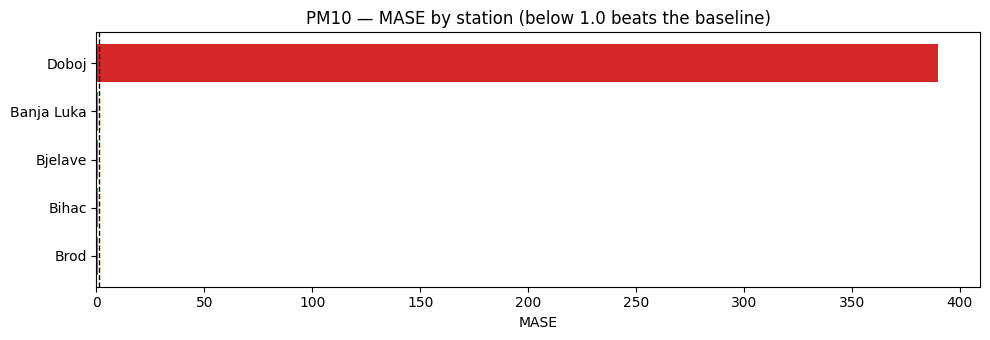

saved xlstm_mase_by_station.png


In [3]:
plot_results()

In [ ]:
full, per_pol = run_all(limit=5)

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

95 total pairs, 95 remaining
running this batch: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Banja Luka-pm10] epoch 1: train MAE (normalized)=80781.0170
[Banja Luka-pm10] epoch 2: train MAE (normalized)=0.5272
[Banja Luka-pm10] epoch 3: train MAE (normalized)=0.4097
[Banja Luka-pm10] epoch 4: train MAE (normalized)=0.3888
[Banja Luka-pm10] epoch 5: train MAE (normalized)=0.3818
[Banja Luka-pm10] epoch 6: train MAE (normalized)=0.3774
[Banja Luka-pm10] epoch 7: train MAE (normalized)=0.3738
[Banja Luka-pm10] epoch 8: train MAE (normalized)=0.3720
[Banja Luka-pm10] epoch 9: train MAE (normalized)=0.3670
[Banja Luka-pm10] epoch 10: train MAE (normalized)=0.3650
[Banja Luka-pm10] epoch 11: train MAE (normalized)=0.3626
[Banja Luka-pm10] epoch 12: train MAE (normalized)=0.3599
[Banja Luka-pm10] epoch 13: train MAE (normalized)=0.3589
[Banja Luka-pm10] epoch 14: train MAE (normalized)=0.3587
[Banja Luka-pm10] epoch 15: train MAE (normalized)=0.3576
[Banja Luka-pm10] epoch 16: train MAE (normalized)=0.3560
[Banja Luka-pm10] epoch 17: train MAE (normalized)=0.3550
[Banja Luka-pm10] e

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

...

[Bjelave-pm10] epoch 1: train MAE (normalized)=26324.5952
[Bjelave-pm10] epoch 2: train MAE (normalized)=0.4745
[Bjelave-pm10] epoch 3: train MAE (normalized)=0.4362
[Bjelave-pm10] epoch 4: train MAE (normalized)=0.4252
[Bjelave-pm10] epoch 5: train MAE (normalized)=0.4186
[Bjelave-pm10] epoch 6: train MAE (normalized)=0.4143
[Bjelave-pm10] epoch 7: train MAE (normalized)=0.4114
[Bjelave-pm10] epoch 8: train MAE (normalized)=0.4091
[Bjelave-pm10] epoch 9: train MAE (normalized)=0.4097
[Bjelave-pm10] epoch 10: train MAE (normalized)=0.4073
[Bjelave-pm10] epoch 11: train MAE (normalized)=0.4041
[Bjelave-pm10] epoch 12: train MAE (normalized)=0.4043
[Bjelave-pm10] epoch 13: train MAE (normalized)=0.4047
[Bjelave-pm10] epoch 14: train MAE (normalized)=0.4021
[Bjelave-pm10] epoch 15: train MAE (normalized)=0.4045
[Bjelave-pm10] epoch 16: train MAE (normalized)=0.4038
[Bjelave-pm10] epoch 17: train MAE (normalized)=0.4005
[Bjelave-pm10] epoch 18: train MAE (normalized)=0.3985
[Bjelave-pm10] 

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Brod-pm10] epoch 1: train MAE (normalized)=29048.6939
[Brod-pm10] epoch 2: train MAE (normalized)=0.4695
[Brod-pm10] epoch 3: train MAE (normalized)=0.4035
[Brod-pm10] epoch 4: train MAE (normalized)=0.3870
[Brod-pm10] epoch 5: train MAE (normalized)=0.3823
[Brod-pm10] epoch 6: train MAE (normalized)=75.5243
[Brod-pm10] epoch 7: train MAE (normalized)=0.3664
[Brod-pm10] epoch 8: train MAE (normalized)=0.3625
[Brod-pm10] epoch 9: train MAE (normalized)=0.3608
[Brod-pm10] epoch 10: train MAE (normalized)=0.3583
[Brod-pm10] epoch 11: train MAE (normalized)=0.3552
[Brod-pm10] epoch 12: train MAE (normalized)=0.3537
[Brod-pm10] epoch 13: train MAE (normalized)=0.3527
[Brod-pm10] epoch 14: train MAE (normalized)=0.3511
[Brod-pm10] epoch 15: train MAE (normalized)=0.3527
[Brod-pm10] epoch 16: train MAE (normalized)=0.3477
[Brod-pm10] epoch 17: train MAE (normalized)=0.3484
[Brod-pm10] epoch 18: train MAE (normalized)=0.3482
[Brod-pm10] epoch 19: train MAE (normalized)=0.3449
[Brod-pm10] epoc

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-pm10] epoch 1: train MAE (normalized)=59890.8315
[Doboj-pm10] epoch 2: train MAE (normalized)=128.3529
[Doboj-pm10] epoch 3: train MAE (normalized)=51.9078
[Doboj-pm10] epoch 4: train MAE (normalized)=0.6068
[Doboj-pm10] epoch 5: train MAE (normalized)=0.5825
[Doboj-pm10] epoch 6: train MAE (normalized)=0.5702
[Doboj-pm10] epoch 7: train MAE (normalized)=0.5632
[Doboj-pm10] epoch 8: train MAE (normalized)=0.5574
[Doboj-pm10] epoch 9: train MAE (normalized)=0.5496
[Doboj-pm10] epoch 10: train MAE (normalized)=0.5415
[Doboj-pm10] epoch 11: train MAE (normalized)=0.5375
[Doboj-pm10] epoch 12: train MAE (normalized)=0.5334
[Doboj-pm10] epoch 13: train MAE (normalized)=0.5322
[Doboj-pm10] epoch 14: train MAE (normalized)=0.5253
[Doboj-pm10] epoch 15: train MAE (normalized)=0.5225
[Doboj-pm10] epoch 16: train MAE (normalized)=0.5199
[Doboj-pm10] epoch 17: train MAE (normalized)=0.5171
[Doboj-pm10] epoch 18: train MAE (normalized)=0.5146
[Doboj-pm10] epoch 19: train MAE (normalized)=0.

In [ ]:
inspect_outliers("Doboj", "pm10")

NameError: name 'inspect_outliers' is not defined

In [ ]:
"""
Doboj-only run + outlier inspection, layered on top of the existing xLSTM
script (xlstm_bih.py). Paste this after that script (or import from it) so
bs, SHARED_DIR, CLEAN_CSV, train_one_station, and evaluate are already
defined.

    from xlstm_bih import *   # or just paste this cell right after it
    full, per_pol = run_doboj()
    outliers = plot_doboj_outliers()
"""

import os
import pandas as pd


def run_doboj(lookback=168, horizon=24, epochs=20, device="cpu",
              out_csv="xlstm_doboj_results.csv"):
    """Same loop as run_all, but restricted to station == 'Doboj', across
    every pollutant Doboj is 'ok' for in groups.json. Appends incrementally
    and skips pairs already in out_csv, same resume behavior as run_all."""
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)

    pairs = [(st, p) for p in bs.POLLUTANTS
             for st in groups["by_pollutant"][p]["ok"] if st == "Doboj"]

    if not pairs:
        status_by_pol = groups["by_station"].get("Doboj", {})
        raise ValueError(
            f"Doboj isn't 'ok' for any pollutant. Its statuses are: {status_by_pol}"
        )

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))
        print(f"{len(done)} Doboj pairs already in {out_csv}, skipping those")

    remaining = [pair for pair in pairs if pair not in done]
    print(f"Doboj: {len(pairs)} eligible pollutants total, {len(remaining)} left to train: {remaining}")

    for station, pollutant in remaining:
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            if len(result) == 0:
                continue
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")

    full = pd.read_csv(out_csv)
    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nDoboj summary, per pollutant, native units:\n")
    print(per_pol)
    return full, per_pol


def plot_doboj_outliers(out_csv="xlstm_doboj_results.csv", iqr_k=1.5):
    """Per-window MASE over time, one panel per pollutant Doboj has results
    for. Outlier windows are flagged with a Tukey IQR fence (q1-1.5*iqr,
    q3+1.5*iqr) computed per pollutant, since MASE scale differs across
    pollutants. Flags both directions — a window with implausibly low MASE
    is usually a scale/data artifact (e.g. a near-constant target hour),
    not the model suddenly getting much better, so it's worth checking too.
    """
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv, parse_dates=["origin"])
    full = full[full.station == "Doboj"]
    if len(full) == 0:
        print(f"no Doboj rows in {out_csv} yet — run run_doboj() first")
        return pd.DataFrame()

    pollutants = sorted(full.pollutant.unique())
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(11, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    outlier_rows = []
    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].sort_values("origin")
        q1, q3 = sub.mase.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - iqr_k * iqr, q3 + iqr_k * iqr
        is_out = (sub.mase < lo) | (sub.mase > hi)

        ax.plot(sub.origin, sub.mase, color="tab:blue", linewidth=1, alpha=0.5)
        ax.scatter(sub.origin[~is_out], sub.mase[~is_out], color="tab:blue", s=14, label="normal")
        ax.scatter(sub.origin[is_out], sub.mase[is_out], color="tab:red", s=45, zorder=5, label="outlier")
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="baseline break-even")
        ax.set_title(f"Doboj — {pollutant.upper()}: MASE per forecast origin "
                     f"({int(is_out.sum())} outlier windows, IQR fence [{lo:.2f}, {hi:.2f}])")
        ax.set_ylabel("MASE")
        ax.legend(loc="upper right", fontsize=8)

        outlier_rows.append(sub[is_out].assign(pollutant=pollutant))

    plt.tight_layout()
    plt.savefig("doboj_mase_outliers.png", dpi=150)
    plt.show()

    outliers = pd.concat(outlier_rows) if outlier_rows else pd.DataFrame()
    if len(outliers):
        cols = [c for c in ["pollutant", "origin", "mase", "mae", "rmse"] if c in outliers.columns]
        print(f"\n{len(outliers)} outlier windows across all Doboj pollutants:\n")
        print(outliers[cols].sort_values("mase", ascending=False).to_string(index=False))
    else:
        print("no outlier windows past the IQR fence")

    print("saved doboj_mase_outliers.png")
    return outliers


if __name__ == "__main__":
    full, per_pol = run_doboj()
    outliers = plot_doboj_outliers()